# Organoid Knowledge Graph — One-Stop User Notebook

**Load, explore, and query the organoid culture database knowledge graph.**

This notebook covers the complete usage pipeline:
1. **Setup** — imports, configuration, dependency check
2. **Load & Statistics** — load a pre-built KG, visualize node/edge distributions
3. **Keyword Search** — search nodes by keyword, with optional type filtering
4. **Graph Traversal** — BFS traversal, path finding, subgraph visualization
5. **GraphRAG Q&A** — LLM-powered question answering over the knowledge graph
6. **Appendix** — node/relationship type reference, troubleshooting

## Prerequisites

```bash
pip install -r scripts/requirements.txt
pip install matplotlib networkx pandas  # optional — for visualization
```

## Before You Start

Make sure you have a knowledge graph file (`organoid_kg.json` or `organoid_kg.sqlite`) in the `organoid-kg-output/` directory. The notebook will auto-detect the latest one.

**Estimated runtime:** Loading ~30s, everything else instant (except LLM calls).

In [1]:
# ── Standard library ──
import json, os, sys, hashlib, datetime, time, textwrap
from collections import Counter, defaultdict
from pprint import pprint

# ── Add scripts/ to path so we can import project modules ──
_scripts_dir = os.path.join(os.getcwd(), "scripts")
if _scripts_dir not in sys.path:
    sys.path.insert(0, _scripts_dir)

# ── Core project imports ──
from query_tool import KnowledgeGraphQuery, GraphNode, GraphEdge

# ── Optional imports (graceful fallback) ──
def _safe_import(package, install_name=None):
    """Try to import a package; return (module, True) or (None, False) with install hint."""
    if install_name is None:
        install_name = package
    try:
        mod = __import__(package)
        return mod, True
    except ImportError:
        return None, False

matplotlib,    HAS_MATPLOTLIB = _safe_import("matplotlib")
plt_mod,       _ = _safe_import("matplotlib.pyplot")
networkx,      HAS_NETWORKX  = _safe_import("networkx")
np,            HAS_NUMPY     = _safe_import("numpy")
pd,            HAS_PANDAS    = _safe_import("pandas")
IPy_display,   HAS_IPYTHON   = _safe_import("IPython.display")

if HAS_MATPLOTLIB:
    import matplotlib.pyplot as plt
    # Configure for CJK-capable fonts (if available)
    for font in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "WenQuanYi Micro Hei", "DejaVu Sans"]:
        try:
            plt.rcParams["font.sans-serif"] = [font] + plt.rcParams["font.sans-serif"]
            break
        except Exception:
            pass
    plt.rcParams["axes.unicode_minus"] = False

if HAS_NETWORKX:
    import networkx as nx

if HAS_IPYTHON:
    from IPython.display import display, Markdown, HTML

print("[OK] Core imports (query_tool ready)")
print(f"  matplotlib:  {'[OK]' if HAS_MATPLOTLIB else '[MISSING] (optional - pip install matplotlib)'}")
print(f"  networkx:    {'[OK]' if HAS_NETWORKX  else '[MISSING] (optional - pip install networkx)'}")
print(f"  pandas:      {'[OK]' if HAS_PANDAS    else '[MISSING] (optional - pip install pandas)'}")
print(f"  IPython:     {'[OK]' if HAS_IPYTHON   else '[MISSING] (optional)'}")


[OK] Core imports (query_tool ready)
  matplotlib:  [OK]
  networkx:    [OK]
  pandas:      [OK]
  IPython:     [OK]


In [2]:
# Print a summary of which optional features are available
deps_status = [
    ("matplotlib", HAS_MATPLOTLIB, "Bar charts, subgraph visualization"),
    ("networkx",   HAS_NETWORKX,  "Graph layout, subgraph rendering"),
    ("pandas",     HAS_PANDAS,    "Rich DataFrames for search results"),
    ("IPython",    HAS_IPYTHON,   "Markdown/HTML display helpers"),
]
print(f"{'Package':<14} {'Status':<10} Feature")
print("-" * 60)
for pkg, ok, feature in deps_status:
    status = "✓ installed" if ok else "✗ missing"
    print(f"{pkg:<14} {status:<10} {feature}")

missing = [p for p, ok, _ in deps_status if not ok]
if missing:
    print(f"\nTo install missing packages:  pip install {' '.join(missing)}")
else:
    print("\n✓ All optional packages available. Full visualization support enabled.")


Package        Status     Feature
------------------------------------------------------------
matplotlib     ✓ installed Bar charts, subgraph visualization
networkx       ✓ installed Graph layout, subgraph rendering
pandas         ✓ installed Rich DataFrames for search results
IPython        ✓ installed Markdown/HTML display helpers

✓ All optional packages available. Full visualization support enabled.


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                        CONFIGURATION HUB                                    ║
# ║  Edit these values before running the notebook.                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# --- Knowledge Graph File Paths ---
KG_OUTPUT_DIR   = "./organoid-kg-output"
KG_JSON_PATH    = None          # Set to a specific .json path, or None to auto-detect
KG_SQLITE_PATH  = None          # Set to a specific .sqlite path, or None to auto-detect

# --- LLM API Configuration (for GraphRAG Q&A in Section 5) ---
LLM_API_KEY  = "sk-xxx"               # API key, or set env vars OPENAI_API_KEY / DEEPSEEK_API_KEY
LLM_BASE_URL = "https://api.deepseek.com"
LLM_MODEL    = "deepseek-v4-pro"

# --- Search & Traversal Defaults ---
DEFAULT_TOP_K           = 20
DEFAULT_TRAVERSAL_DEPTH = 2
DEFAULT_MAX_SAMPLES     = 30

# --- Visualization ---
VIZ_FIG_SIZE           = (12, 6)
VIZ_TOP_N             = 15
VIZ_MAX_SUBGRAPH_NODES = 50

print(f"✓ KG output directory: {os.path.abspath(KG_OUTPUT_DIR)}")
if not LLM_API_KEY:
    print("⚠  LLM_API_KEY is empty. GraphRAG Q&A (Section 4) requires an API key.")
    print("   Set LLM_API_KEY or the DEEPSEEK_API_KEY / OPENAI_API_KEY environment variable.")


✓ KG output directory: D:\PycharmProjects\pub_database\build_graphRAG\organoid-kg-output


---
## Section 1: Load Knowledge Graph & Explore Statistics

Load the knowledge graph from a file (JSON or SQLite) and explore its structure —
node types, relationship types, and key entities.

In [4]:
# Cell 1.1 — Auto-detect or specify the KG file to load
def _find_latest_kg(base_dir):
    """Scan timestamped subdirectories for the latest organoid_kg.json."""
    if not os.path.isdir(base_dir):
        return None
    subdirs = []
    for name in os.listdir(base_dir):
        full = os.path.join(base_dir, name)
        if os.path.isdir(full):
            # Match YYYY-MM-DD-HHMM pattern
            parts = name.split("-")
            if len(parts) >= 4 and all(p.isdigit() for p in parts[:4]):
                kg_file = os.path.join(full, "organoid_kg.json")
                if os.path.isfile(kg_file):
                    subdirs.append((name, kg_file))
    if not subdirs:
        return None
    subdirs.sort(key=lambda x: x[0], reverse=True)
    return subdirs[0][1]

# Determine LOAD_PATH
LOAD_PATH = None
source = ""

# Priority 1: explicit config
if KG_JSON_PATH and os.path.isfile(KG_JSON_PATH):
    LOAD_PATH = KG_JSON_PATH
    source = "KG_JSON_PATH config"
elif KG_SQLITE_PATH and os.path.isfile(KG_SQLITE_PATH):
    LOAD_PATH = KG_SQLITE_PATH
    source = "KG_SQLITE_PATH config"

# Priority 2: auto-detect from output directory
if LOAD_PATH is None:
    LOAD_PATH = _find_latest_kg(KG_OUTPUT_DIR)
    if LOAD_PATH:
        source = f"auto-detected in {KG_OUTPUT_DIR}"

if LOAD_PATH:
    size_mb = os.path.getsize(LOAD_PATH) / (1024 * 1024)
    print(f"KG file: {LOAD_PATH}")
    print(f"Source:  {source}")
    print(f"Size:    {size_mb:.1f} MB")
else:
    print("⚠  No KG file found.")
    print("   Options:")
    print(f"   1. Set KG_JSON_PATH or KG_SQLITE_PATH in the Configuration cell")
    print(f"   2. Place a .json or .sqlite file under {KG_OUTPUT_DIR}")
    print(f"   3. Run build_kg.py to construct a new KG from the database")


KG file: ./organoid-kg-output\2026-07-23-1524\organoid_kg.json
Source:  auto-detected in ./organoid-kg-output
Size:    5215.6 MB


In [5]:
# Cell 1.2 — Load the knowledge graph into memory
if LOAD_PATH is not None:
    print(f"Loading KG from: {LOAD_PATH}")
    print("(Large JSON files may take 30-60 seconds; SQLite is faster)\n")
    try:
        t0 = time.time()
        kg = KnowledgeGraphQuery.load(LOAD_PATH)
        elapsed = time.time() - t0
        print(f"✓ Loaded in {elapsed:.1f}s")
        print(f"  Nodes: {len(kg.nodes):,}  |  Edges: {len(kg.edges):,}")
        print(f"  Node types: {len(kg._type_index)}  |  Memory footprint: ~{len(kg.nodes) * 0.5:.0f} KB estimated")
    except MemoryError:
        print("[ERROR] Not enough memory to load the JSON file.")
        print("[HINT] Use the SQLite format instead — it loads incrementally:")
        print("       Set KG_SQLITE_PATH in the Configuration cell.")
    except FileNotFoundError:
        print(f"[ERROR] File not found: {LOAD_PATH}")
    except Exception as e:
        print(f"[ERROR] {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
else:
    print("LOAD_PATH is not set. Run Cell 1.1 first.")
    kg = None


Loading KG from: ./organoid-kg-output\2026-07-23-1524\organoid_kg.json
(Large JSON files may take 30-60 seconds; SQLite is faster)

[OK] Loaded knowledge graph: 406602 nodes, 1452471 edges
✓ Loaded in 231.2s
  Nodes: 406,602  |  Edges: 1,452,471
  Node types: 34  |  Memory footprint: ~203301 KB estimated


In [6]:
# Cell 1.3 — Print knowledge graph statistics
if kg is not None:
    kg.print_stats()

    stats = kg.stats()
    print(f"\nAdditional metrics:")
    print(f"  Average degree:  {stats['avg_degree']:.2f}")
    print(f"  Max degree:      {stats['max_degree']}")
    print(f"  Isolated nodes:  {stats['isolated_nodes']}")
else:
    print("KG not loaded. Run Cell 1.2 first.")



  Knowledge Graph Statistics
  Total nodes:         406602
  Total edges:        1452471
  Average degree:        7.14
  Max degree:           23578
  Isolated nodes:           0

  Nodes by type:
    MaterialInfo             : 101941
    GSEA                     :  29164
    GroupDEGs                :  27619
    Biomarker                :  26234
    GSVA                     :  24492
    CellFactor               :  20125
    Phenotype                :  17984
    Sample                   :  17055
    CultureProtocol          :  16947
    ApplicationStrategy      :  16900
    Technology               :  15869
    GeneAnnotation           :  15354
    OrganoidProfile          :  14028
    Publication              :  12473
    Composition              :  10518
    CultureCondition         :   8199
    ClusterMarkers           :   6000
    IntraClusterDEGs         :   5904
    Drug                     :   4255
    DiseaseModel             :   4038
    GroupInfo                :   2964
    

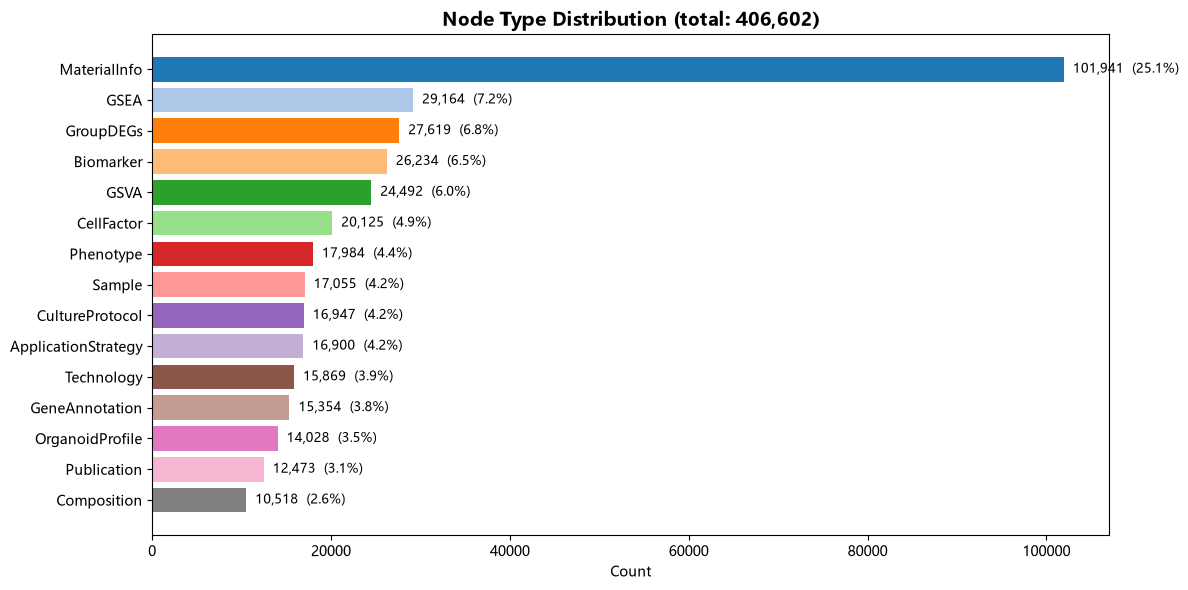

In [7]:
# Cell 1.4 — Visualize node type distribution
def plot_node_type_distribution(node_type_counts, top_n=15, figsize=(12, 6)):
    """Horizontal bar chart of node type distribution."""
    if not HAS_MATPLOTLIB:
        print("matplotlib not installed. Install with: pip install matplotlib")
        # Fallback: text table
        print(f"\n{'Node Type':<20} {'Count':>8} {'Pct':>8}")
        print("-" * 40)
        total = sum(node_type_counts.values())
        for t, c in sorted(node_type_counts.items(), key=lambda x: -x[1])[:top_n]:
            print(f"{t:<20} {c:>8,} {c/total*100:>7.1f}%")
        return

    items = sorted(node_type_counts.items(), key=lambda x: -x[1])[:top_n]
    types, counts = zip(*items)
    total = sum(node_type_counts.values())

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab20(range(len(types)))
    bars = ax.barh(range(len(types)), counts, color=colors)

    ax.set_yticks(range(len(types)))
    ax.set_yticklabels(types)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Node Type Distribution (total: {total:,})", fontsize=14, fontweight="bold")

    for i, (t, c) in enumerate(zip(types, counts)):
        pct = c / total * 100
        ax.text(c + max(counts) * 0.01, i, f"{c:,}  ({pct:.1f}%)", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

if kg is not None:
    plot_node_type_distribution(kg.stats()["nodes_by_type"], top_n=VIZ_TOP_N, figsize=VIZ_FIG_SIZE)
else:
    print("KG not loaded. Run Cell 1.2 first.")


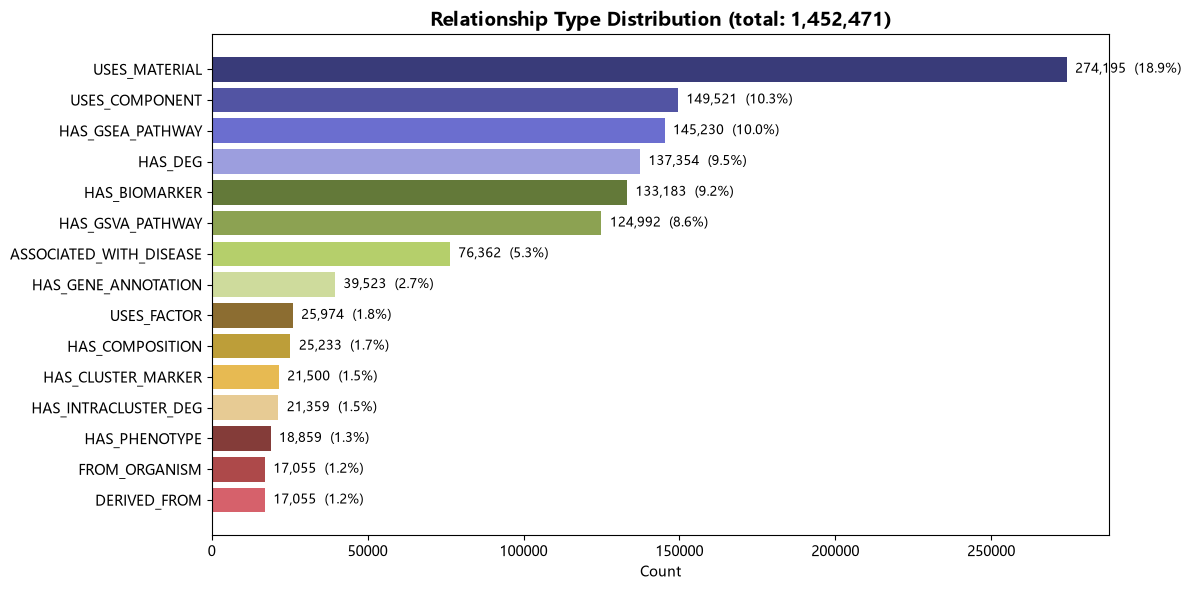

In [8]:
# Cell 1.5 — Visualize relationship type distribution
def plot_relation_distribution(edge_type_counts, top_n=15, figsize=(12, 6)):
    """Horizontal bar chart of relationship type distribution."""
    if not HAS_MATPLOTLIB:
        total = sum(edge_type_counts.values())
        print(f"{'Relation':<25} {'Count':>8} {'Pct':>8}")
        print("-" * 45)
        for r, c in sorted(edge_type_counts.items(), key=lambda x: -x[1])[:top_n]:
            print(f"{r:<25} {c:>8,} {c/total*100:>7.1f}%")
        return

    items = sorted(edge_type_counts.items(), key=lambda x: -x[1])[:top_n]
    relations, counts = zip(*items)
    total = sum(edge_type_counts.values())

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab20b(range(len(relations)))
    bars = ax.barh(range(len(relations)), counts, color=colors)

    ax.set_yticks(range(len(relations)))
    ax.set_yticklabels(relations)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Relationship Type Distribution (total: {total:,})", fontsize=14, fontweight="bold")

    for i, (r, c) in enumerate(zip(relations, counts)):
        pct = c / total * 100
        ax.text(c + max(counts) * 0.01, i, f"{c:,}  ({pct:.1f}%)", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

if kg is not None:
    plot_relation_distribution(kg.stats()["edges_by_relation"], top_n=VIZ_TOP_N, figsize=VIZ_FIG_SIZE)
else:
    print("KG not loaded. Run Cell 1.2 first.")


In [9]:
# Cell 1.6 — Top-5 most-connected entities by major type
if kg is not None:
    major_types = ["Drug", "CellFactor", "Gene", "DiseaseModel", "Biomarker", "Technology"]
    print(f"{'Type':<16} {'Degree':>6}  {'Name':<40}  ID")
    print("-" * 90)
    for ntype in major_types:
        # Get all node IDs of this type
        node_ids = kg._type_index.get(ntype, [])
        if not node_ids:
            continue
        # Compute degree from adjacency
        scored = []
        for nid in node_ids:
            degree = len(kg._adjacency.get(nid, []))
            scored.append((degree, nid))
        scored.sort(key=lambda x: -x[0])
        for rank, (degree, nid) in enumerate(scored[:5]):
            node = kg.nodes[nid]
            name = node.properties.get("name", nid)[:40]
            marker = "←" if rank == 0 else " "
            print(f"  {marker} {ntype:<14} {degree:>6}  {name:<40}  {nid}")
        print()
else:
    print("KG not loaded. Run Cell 1.2 first.")

Type             Degree  Name                                      ID
------------------------------------------------------------------------------------------
  ← Drug              670  cisplatin                                 drg_492d36f2
    Drug              403  paclitaxel                                drg_74546d3d
    Drug              377  gemcitabine                               drg_e222d1c4
    Drug              353  Oxaliplatin                               drg_f00be86b
    Drug              324  doxorubicin                               drg_b3682bbc

  ← CellFactor      10397  not specified                             cf_ebe2d81e
    CellFactor       5785  egf                                       cf_966b6949
    CellFactor       4010  noggin                                    cf_3ca1ae49
    CellFactor       3811  glutamax                                  cf_4d2a1fdb
    CellFactor       3085  penicillin-streptomycin                   cf_ba3bd137

  ← Gene              

---
## Section 2: Keyword Search & Query

The `kg.search()` method splits your query into space-separated keywords and scores
each node by the fraction of keywords matched (AND logic). You can optionally filter
by node type for targeted lookups.


In [10]:
# Cell 2.1 — Basic keyword search (5 demo queries)
if kg is not None:
    demo_queries = [
        "EGF Wnt R-spondin",
        "intestinal organoid",
        "Colorectal Cancer",
        "CRISPR",
        "Cisplatin",
    ]
    for query in demo_queries:
        results = kg.search(query, top_k=5)
        print(f"\n{'─' * 70}")
        print(f'Query: "{query}"  →  {len(results)} results')
        print(f"{'─' * 70}")
        for node, score in results[:5]:
            name = node.properties.get("name", node.properties.get("sample_id", node.id))
            name_str = str(name)[:55]
            print(f"  [{node.type:<15}] {name_str:<55}  score={score:.2f}  id={node.id}")
else:
    print("KG not loaded. Run Cell 1.2 first.")



──────────────────────────────────────────────────────────────────────
Query: "EGF Wnt R-spondin"  →  5 results
──────────────────────────────────────────────────────────────────────
  [CultureProtocol] cpr_51a55e4e                                             score=1.00  id=cpr_51a55e4e
  [CultureProtocol] cpr_63357d51                                             score=1.00  id=cpr_63357d51
  [CultureProtocol] cpr_233abeb4                                             score=1.00  id=cpr_233abeb4
  [CultureProtocol] cpr_e257d22d                                             score=1.00  id=cpr_e257d22d
  [CultureProtocol] cpr_d5e50a75                                             score=1.00  id=cpr_d5e50a75

──────────────────────────────────────────────────────────────────────
Query: "intestinal organoid"  →  5 results
──────────────────────────────────────────────────────────────────────
  [ApplicationStrategy] [{"application":"toxicity testing","factor":"Ag, SiO2,   score=1.00  id=ast_10445

In [11]:
# Cell 2.2 — Type-filtered search
if kg is not None:
    def search_and_display(kg_obj, query, node_type, top_k=10):
        """Search with type filter and print formatted results."""
        results = kg_obj.search(query, node_type=node_type, top_k=top_k)
        print(f'\nSearch: "{query}"  [type={node_type}]')
        print(f"Results: {len(results)}")
        for node, score in results[:top_k]:
            name = node.properties.get("name", "?")
            extra = ""
            if "category" in node.properties:
                extra = f" | category: {node.properties['category']}"
            print(f"  [{node.type}] {name}{extra}  —  score={score:.2f}  id={node.id}")
        return results

    # Drug search
    search_and_display(kg, "Cisplatin", "Drug")
    # Biomarker search
    search_and_display(kg, "Lgr5", "Biomarker")
    # Gene search
    search_and_display(kg, "APC", "Gene")
    # Organ search
    search_and_display(kg, "Liver", "Organ")
else:
    print("KG not loaded. Run Cell 1.2 first.")



Search: "Cisplatin"  [type=Drug]
Results: 10
  [Drug] cisplatin  —  score=1.00  id=drg_492d36f2
  [Drug] CDDP (Cisplatin)  —  score=1.00  id=drg_c658c837
  [Drug] cisplatin (DDP)  —  score=1.00  id=drg_a4e0aad9
  [Drug] paclitaxel plus cisplatin (TP)  —  score=1.00  id=drg_3584b186
  [Drug] vinorelbine plus cisplatin (NP)  —  score=1.00  id=drg_58677f8b
  [Drug] 5-fluorouracil plus cisplatin (FP)  —  score=1.00  id=drg_2045f210
  [Drug] Cisplatin (CDDP)  —  score=1.00  id=drg_340a5fb0
  [Drug] irinotecan plus cisplatin  —  score=1.00  id=drg_ac015eed
  [Drug] kenpaullone  —  score=1.00  id=drg_42d80ce7
  [Drug] Tizanidine  —  score=1.00  id=drg_656e42af

Search: "Lgr5"  [type=Biomarker]
Results: 10
  [Biomarker] Lgr5  —  score=1.00  id=bmk_3b058f6f
  [Biomarker] p-P53  —  score=1.00  id=bmk_2899bc21
  [Biomarker] γ-H2AX  —  score=1.00  id=bmk_a5e1ed78
  [Biomarker] Cleaved Caspase 3  —  score=1.00  id=bmk_715b8f85
  [Biomarker] CACNA1C  —  score=1.00  id=bmk_7ed75134
  [Biomarker] GAB

In [12]:
# Cell 2.3 — Explore a search result's neighborhood
if kg is not None:
    # Re-run a search to get a seed node
    seed_results = kg.search("EGF", top_k=1)
    if seed_results:
        seed_node, seed_score = seed_results[0]
        seed_name = seed_node.properties.get("name", seed_node.properties.get("sample_id", seed_node.id))
        print(f"Seed node: [{seed_node.type}] {seed_name}  (score={seed_score:.2f}, id={seed_node.id})\n")

        sub = kg.traverse(seed_node.id, depth=1)
        print(f"1-hop subgraph: {len(sub['nodes'])} nodes, {len(sub['edges'])} edges\n")

        # Group neighbors by type
        neighbors_by_type = defaultdict(list)
        for edge in sub["edges"]:
            if edge.source == seed_node.id:
                neighbor = kg.nodes.get(edge.target)
            elif edge.target == seed_node.id:
                neighbor = kg.nodes.get(edge.source)
            else:
                continue
            if neighbor and neighbor.id != seed_node.id:
                neighbors_by_type[neighbor.type].append((neighbor, edge.relation))

        for ntype, items in sorted(neighbors_by_type.items()):
            print(f"  [{ntype}] ({len(items)} connections):")
            for neighbor, rel in items[:5]:
                name = neighbor.properties.get("name", neighbor.id)
                print(f"    --[{rel}]--> {str(name)[:60]}")
            if len(items) > 5:
                print(f"    ... and {len(items) - 5} more")
            print()
    else:
        print("No search results found for 'EGF'. Try a different query.")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Seed node: [CultureProtocol] cpr_51a55e4e  (score=1.00, id=cpr_51a55e4e)

1-hop subgraph: 37 nodes, 21268 edges

  [CellFactor] (16 connections):
    --[USES_COMPONENT]--> egf
    --[USES_COMPONENT]--> fgf2
    --[USES_COMPONENT]--> r-spondin1-conditioned medium
    --[USES_COMPONENT]--> wnt3a-conditioned medium
    --[USES_COMPONENT]--> dexamethasone
    ... and 11 more

  [MaterialInfo] (19 connections):
    --[USES_MATERIAL]--> Advanced DMEM/F12
    --[USES_MATERIAL]--> Penicillin-Streptomycin
    --[USES_MATERIAL]--> a-MEM GlutaMAX
    --[USES_MATERIAL]--> epidermal growth factor
    --[USES_MATERIAL]--> bFGF
    ... and 14 more

  [Sample] (1 connections):
    --[USES_PROTOCOL]--> smp_KM-00002



---
## Section 3: Graph Traversal & Path Finding

Graph traversal uses **BFS (breadth-first search)** to expand outward from a seed node.
Path finding discovers the shortest connecting routes between two arbitrary nodes.


In [13]:
# Cell 3.1 — Traverse from a sample node at different depths
if kg is not None:
    # Auto-select a sample node
    sample_ids = kg._type_index.get("Sample", [])
    if not sample_ids:
        print("No Sample nodes found in the KG.")
    else:
        sample_id = sample_ids[0]
        sample_node = kg.nodes[sample_id]
        sample_name = sample_node.properties.get("sample_id", sample_id)
        print(f"Sample node: {sample_name}  (id={sample_id})\n")

        for depth in [1, 2, 3]:
            sub = kg.traverse(sample_id, depth=depth)
            node_count = len(sub["nodes"])
            edge_count = len(sub["edges"])
            # Count types in subgraph
            type_counts = Counter(n.type for n in sub["nodes"])
            print(f"  depth={depth}: {node_count:,} nodes, {edge_count:,} edges  "
                  f"| types: {dict(type_counts)}")

        # Detailed 1-hop view
        print(f"\n{'─' * 60}")
        print("1-hop detail:")
        sub1 = kg.traverse(sample_id, depth=1)
        neighbors_by_type = defaultdict(list)
        for edge in sub1["edges"]:
            neighbor_id = edge.target if edge.source == sample_id else edge.source
            if neighbor_id != sample_id:
                neighbor = kg.nodes.get(neighbor_id)
                if neighbor:
                    neighbors_by_type[neighbor.type].append((neighbor, edge.relation))

        for ntype, items in sorted(neighbors_by_type.items()):
            print(f"\n  [{ntype}] ({len(items)}):")
            for neighbor, rel in items[:8]:
                name = neighbor.properties.get("name", neighbor.id)
                print(f"    --[{rel}]--> {str(name)[:60]}")
            if len(items) > 8:
                print(f"    ... and {len(items) - 8} more")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Sample node: KM-00001  (id=smp_KM-00001)

  depth=1: 24 nodes, 53,162 edges  | types: {'Biomarker': 8, 'Organism': 1, 'CultureCondition': 1, 'Composition': 1, 'Sample': 1, 'ApplicationStrategy': 1, 'CoCultureProtocol': 1, 'DiseaseModel': 1, 'CultureTechnique': 1, 'Application': 1, 'OrganoidProfile': 1, 'Source': 1, 'Organ': 1, 'Technology': 1, 'Test': 1, 'Publication': 1, 'CultureProtocol': 1}
  depth=2: 31,956 nodes, 499,689 edges  | types: {'Biomarker': 14576, 'Sample': 15466, 'Drug': 1737, 'DiseaseModel': 150, 'Technology': 1, 'System': 1, 'MaterialInfo': 10, 'Organism': 1, 'CultureCondition': 1, 'CellFactor': 2, 'Composition': 1, 'OrganoidProfile': 1, 'Source': 1, 'CultureTechnique': 1, 'CultureProtocol': 1, 'Publication': 1, 'CoCultureProtocol': 1, 'Application': 1, 'ApplicationStrategy': 1, 'Test': 1, 'Organ': 1}
  depth=3: 163,039 nodes, 1,326,109 edges  | types: {'ApplicationStrategy': 15334, 'Phenotype': 15561, 'Sample': 16920, 'Biomarker': 23880, 'Application': 1302, 'Culture

In [14]:
# Cell 3.2 — Find paths between two nodes
if kg is not None:
    # Auto-select: pick one Drug and one DiseaseModel
    drug_ids = kg._type_index.get("Drug", [])
    disease_ids = kg._type_index.get("DiseaseModel", [])

    if drug_ids and disease_ids:
        drug_id = drug_ids[0]
        disease_id = disease_ids[0]
        drug_name = kg.nodes[drug_id].properties.get("name", drug_id)
        disease_name = kg.nodes[disease_id].properties.get("name", disease_id)

        print(f"Finding paths:")
        print(f"  From: [{kg.nodes[drug_id].type}] {drug_name}")
        print(f"  To:   [{kg.nodes[disease_id].type}] {disease_name}\n")

        paths = kg.find_paths(drug_id, disease_id, max_length=4)
        print(f"Found {len(paths)} path(s):\n")

        for i, path in enumerate(paths[:5]):
            print(f"  Path {i + 1}:")
            for step in path:
                from_name = step["from_node"].properties.get("name", step["from_node"].id)
                to_name = step["to_node"].properties.get("name", step["to_node"].id)
                print(f"    [{step['from_node'].type}] {str(from_name)[:40]}")
                print(f"      --[{step['edge'].relation}]-->")
                print(f"    [{step['to_node'].type}] {str(to_name)[:40]}")
                print()
    else:
        print("Need both Drug and DiseaseModel nodes in the KG to demonstrate path finding.")
        print(f"  Drugs: {len(drug_ids)}  |  DiseaseModels: {len(disease_ids)}")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Finding paths:
  From: [Drug] Urolithin A
  To:   [DiseaseModel] not specified

Found 10 path(s):

  Path 1:
    [Drug] Urolithin A
      --[ASSOCIATED_WITH_DISEASE]-->
    [DiseaseModel] not specified

  Path 2:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample] smp_KM-00002
      --[MODELS_DISEASE]-->
    [DiseaseModel] not specified

  Path 3:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample] smp_KM-00002
      --[SCREENS_DRUG]-->
    [Drug] PMI

    [Drug] PMI
      --[ASSOCIATED_WITH_DISEASE]-->
    [DiseaseModel] not specified

  Path 4:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample] smp_KM-00002
      --[HAS_BIOMARKER]-->
    [Biomarker] Caspase-3/7 activity

    [Biomarker] Caspase-3/7 activity
      --[ASSOCIATED_WITH_DISEASE]-->
    [DiseaseModel] not specified

  Path 5:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample]

Visualizing subgraph around Sample: smp_KM-00004


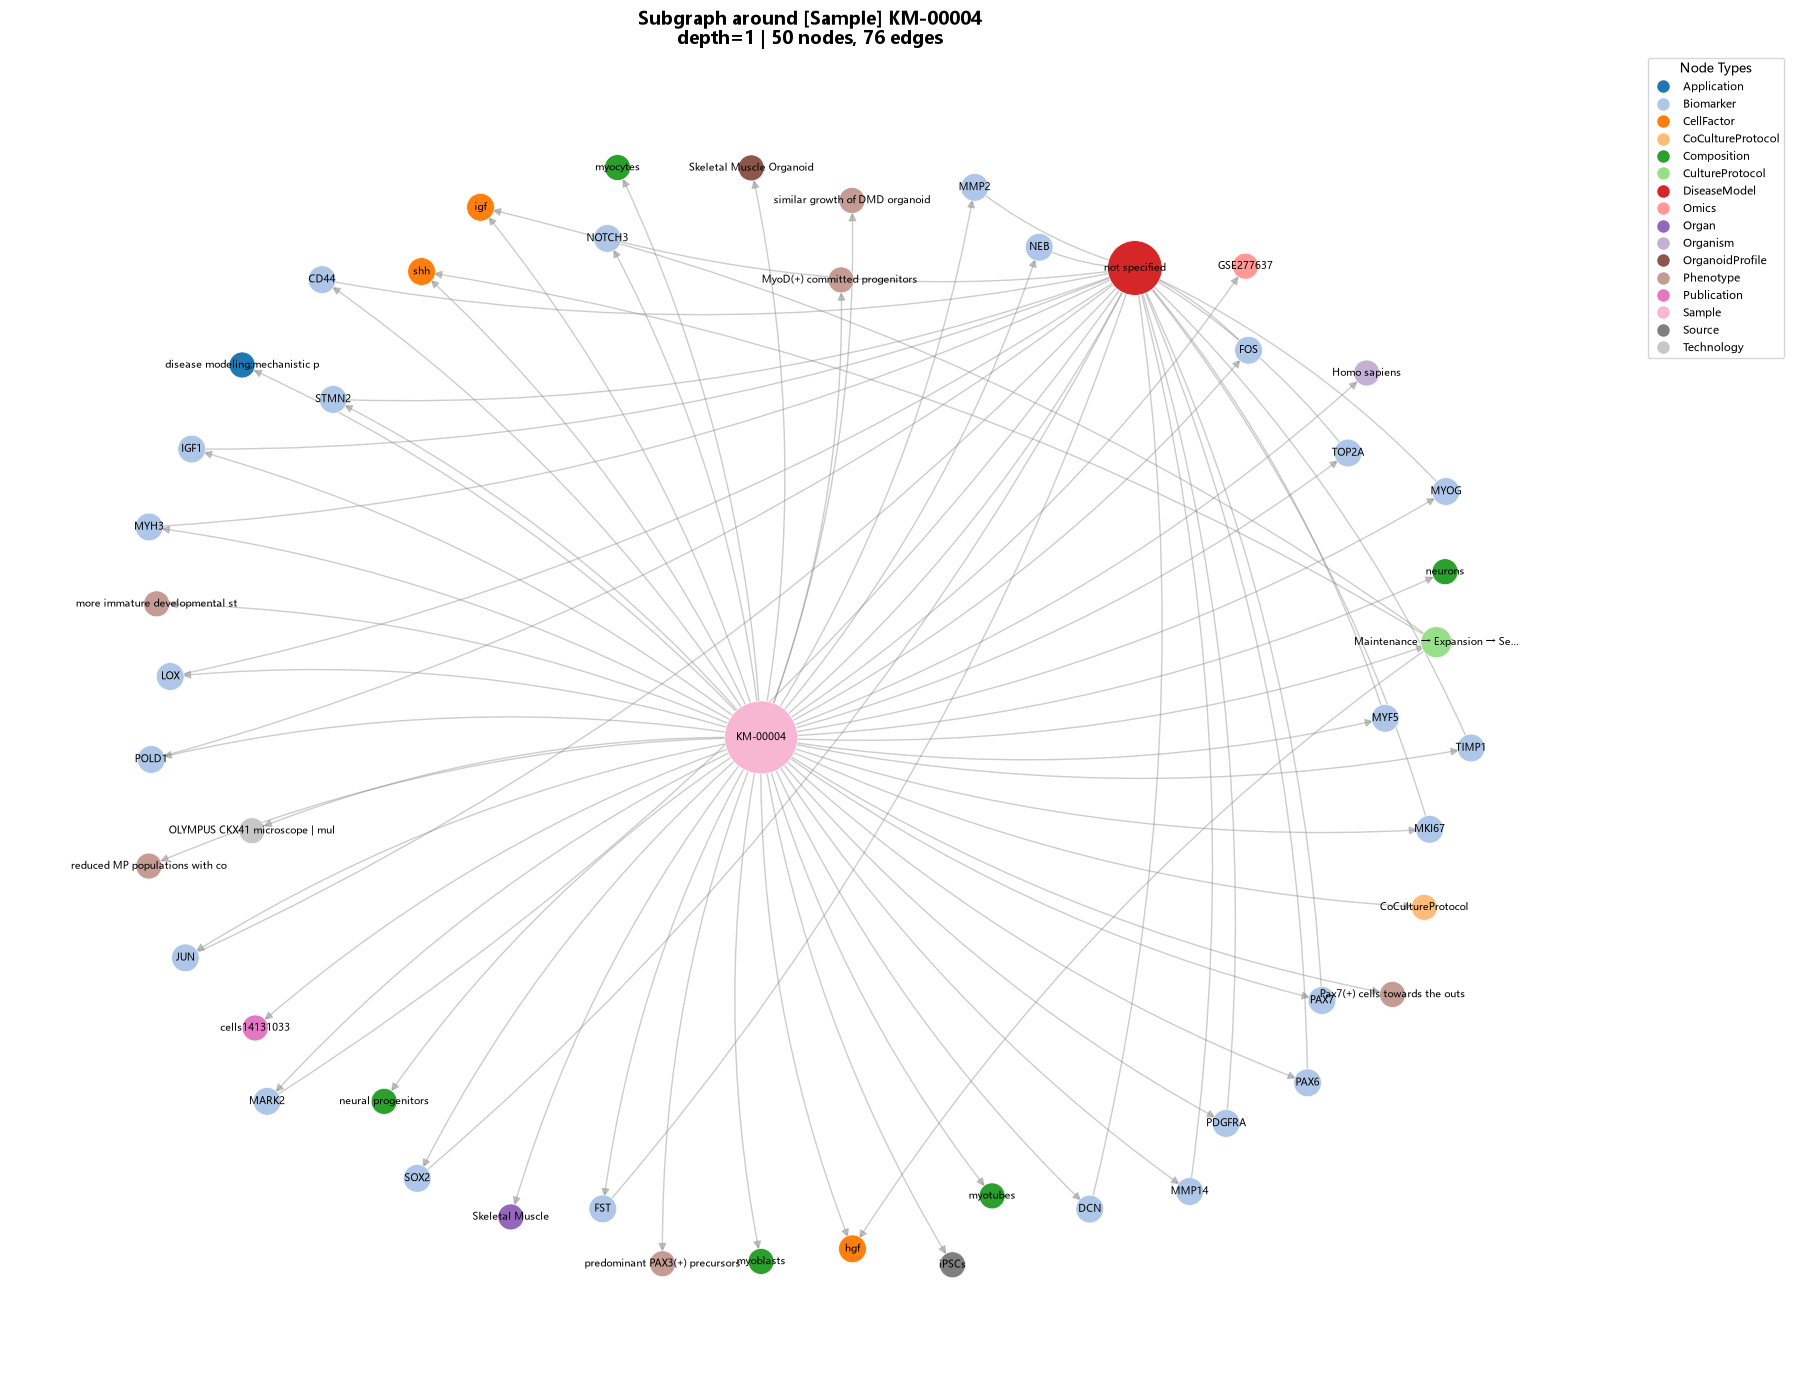


💡 50 nodes — set max_nodes ≤15 or depth=1 to see per-node detail table.


In [15]:
# Cell 3.3 — Visualize a subgraph with networkx (enhanced with per-type attribute display)

def _get_node_display_info(node):
    """Extract (primary_label, secondary_info) for a node based on its type.

    Returns (primary_label, secondary_string) where:
      - primary_label: short name shown ON the node (≤30 chars)
      - secondary_string: key attributes shown BELOW the node (≤60 chars), or ""

    Covers all 33 node types defined in the KG schema.
    """
    props = node.properties
    ntype = node.type
    primary = ""
    secondary_parts = []

    # ── Sample ──
    if ntype == "Sample":
        primary = props.get("sample_id") or props.get("name", "")
        year = props.get("year", "")
        if year:
            secondary_parts.append(f"Y:{year}")

    # ── Organism ──
    elif ntype == "Organism":
        primary = props.get("name", "")

    # ── Organ ──
    elif ntype == "Organ":
        primary = props.get("name", "")

    # ── System ──
    elif ntype == "System":
        raw = props.get("name", "")
        try:
            data = json.loads(raw) if isinstance(raw, str) else raw
            if isinstance(data, list):
                primary = ", ".join(str(x)[:20] for x in data[:2])
            else:
                primary = str(raw)[:25]
        except Exception:
            primary = str(raw)[:25]

    # ── Source ──
    elif ntype == "Source":
        primary = props.get("name", "")

    # ── DiseaseModel ──
    elif ntype == "DiseaseModel":
        primary = props.get("name", "")

    # ── Application ──
    elif ntype == "Application":
        primary = props.get("name", "")

    # ── ApplicationStrategy (JSON list of objects) ──
    elif ntype == "ApplicationStrategy":
        raw = props.get("name", "")
        try:
            data = json.loads(raw) if isinstance(raw, str) else raw
            if isinstance(data, list) and data:
                item = data[0]
                if isinstance(item, dict):
                    app = item.get("application", "")
                    factor = item.get("factor", "")
                    if app:
                        primary = str(app)[:30]
                    if factor:
                        secondary_parts.append(str(factor)[:25])
                else:
                    primary = str(raw)[:30]
            else:
                primary = str(raw)[:30]
        except Exception:
            primary = str(raw)[:30]

    # ── Publication ──
    elif ntype == "Publication":
        doi = props.get("name", "")
        if "/" in doi:
            primary = doi.rsplit("/", 1)[-1][:25]
        else:
            primary = doi[:25]

    # ── Gene ──
    elif ntype == "Gene":
        primary = props.get("name", "")
        method = props.get("editing_method", "")
        if method:
            secondary_parts.append(method)

    # ── CellFactor ──
    elif ntype == "CellFactor":
        primary = props.get("name", "")
        conc = props.get("concentration", "")
        if conc:
            secondary_parts.append(conc)

    # ── Technology (name is raw JSON — extract meaningful bits) ──
    elif ntype == "Technology":
        raw = props.get("name", "")
        try:
            tech = json.loads(raw) if isinstance(raw, str) else raw
            if isinstance(tech, dict):
                bits = []
                for category in ["cellular_imaging", "molecular_analysis",
                                 "in_vivo_models", "other_techniques"]:
                    cat_val = tech.get(category)
                    if isinstance(cat_val, dict):
                        for subk, subv in cat_val.items():
                            if not subv:
                                continue
                            if isinstance(subv, list) and subv:
                                item = subv[0]
                                if isinstance(item, dict):
                                    bits.append(item.get("device") or item.get("name") or subk)
                                else:
                                    bits.append(str(item)[:18])
                            elif isinstance(subv, str):
                                bits.append(subv[:18])
                            elif isinstance(subv, dict):
                                bits.append(subv.get("device") or subv.get("name") or subk)
                            break  # first non-null sub-key only
                primary = " | ".join(bits[:2]) if bits else "Technology"
            else:
                primary = str(raw)[:30]
        except Exception:
            primary = str(raw)[:30] if raw else "Technology"

    # ── Drug ──
    elif ntype == "Drug":
        primary = props.get("drug") or props.get("name", "")
        disease = props.get("disease", "")
        if disease and len(str(disease)) < 50:
            secondary_parts.append(str(disease)[:30])
        resp = props.get("drug_response", "")
        if resp and resp != "Drug efficacy testing":
            secondary_parts.append(str(resp)[:25])

    # ── Infection ──
    elif ntype == "Infection":
        primary = props.get("agent_name") or props.get("name", "")
        mtype = props.get("microorganism_type", "")
        if mtype:
            secondary_parts.append(mtype)
        disease = props.get("disease_or_model", "")
        if disease:
            secondary_parts.append(str(disease)[:25])

    # ── Biomarker ──
    elif ntype == "Biomarker":
        bmk = props.get("biomarker_name", {})
        if isinstance(bmk, dict):
            primary = bmk.get("std") or bmk.get("src") or props.get("name", "")
        else:
            primary = str(bmk) if bmk else props.get("name", "")
        for key in ("biomarker_type", "detection_method", "pathway"):
            v = props.get(key, "")
            if v:
                secondary_parts.append(str(v)[:25])

    # ── Phenotype ──
    elif ntype == "Phenotype":
        primary = props.get("phenotype") or props.get("name", "")
        method = props.get("identification_method", "")
        if method:
            secondary_parts.append(str(method)[:30])

    # ── Test (JSON list) ──
    elif ntype == "Test":
        raw = props.get("name", "")
        try:
            data = json.loads(raw) if isinstance(raw, str) else raw
            if isinstance(data, list):
                primary = ", ".join(str(x)[:20] for x in data[:2])
            else:
                primary = str(raw)[:30]
        except Exception:
            primary = str(raw)[:30]

    # ── Omics ──
    elif ntype == "Omics":
        primary = props.get("omics_id") or props.get("name", "")
        otype = props.get("omics_type", "")
        osub = props.get("omics_subtype", "")
        if osub:
            secondary_parts.append(osub)
        elif otype:
            secondary_parts.append(otype)

    # ── Composition ──
    elif ntype == "Composition":
        primary = props.get("cell_type") or props.get("name", "")
        species = props.get("species", "")
        if species:
            secondary_parts.append(str(species)[:20])
        organ_list = props.get("organ", [])
        if organ_list:
            secondary_parts.append(",".join(str(o)[:12] for o in organ_list[:2]))

    # ── Platform ──
    elif ntype == "Platform":
        primary = props.get("name", "")
        cat = props.get("category", "")
        if cat:
            secondary_parts.append(cat)

    # ── CultureProtocol ──
    elif ntype == "CultureProtocol":
        summary = props.get("summary", "")
        primary = (summary[:28] + "…") if len(summary) > 28 else summary
        gfs = props.get("growth_factor_names", [])
        if gfs:
            secondary_parts.append("GFs:" + ",".join(str(x)[:10] for x in gfs[:3]))
        sms = props.get("small_molecule_names", [])
        if sms:
            secondary_parts.append("SMs:" + ",".join(str(x)[:10] for x in sms[:2]))
        media = props.get("media_used", [])
        if media and not gfs:
            secondary_parts.append("media:" + ",".join(str(x)[:12] for x in media[:2]))

    # ── CoCultureProtocol ──
    elif ntype == "CoCultureProtocol":
        summary = props.get("summary", "")
        primary = (summary[:25] + "…") if len(summary) > 25 else (summary or "CoCultureProtocol")
        gfs = props.get("growth_factor_names", [])
        if gfs:
            secondary_parts.append("GFs:" + ",".join(str(x)[:10] for x in gfs[:2]))

    # ── CultureTechnique ──
    elif ntype == "CultureTechnique":
        primary = props.get("subcategory") or props.get("full_description", "")
        cat = props.get("category", "")
        if cat:
            secondary_parts.append(cat[:25])

    # ── CoCultureTechnique ──
    elif ntype == "CoCultureTechnique":
        primary = props.get("full_description") or props.get("name", "")

    # ── CultureCondition ──
    elif ntype == "CultureCondition":
        desc = props.get("description", "")
        primary = desc[:30] if desc else props.get("name", "")
        conds = props.get("conditions", [])
        if conds:
            secondary_parts.append(", ".join(str(c)[:20] for c in conds[:2]))

    # ── OrganoidProfile ──
    elif ntype == "OrganoidProfile":
        primary = props.get("display_name") or props.get("name", "")
        maturity = props.get("maturity", "")
        if maturity and maturity != "not specified":
            secondary_parts.append(str(maturity)[:25])

    # ── GroupInfo (cross-table lookup from public_search_pathway) ──
    elif ntype == "GroupInfo":
        primary = props.get("name") or props.get("factor", "")
        group = props.get("group", "")
        if group:
            secondary_parts.append(f"grp:{group}")
        gse = props.get("GSE_ID", "")
        if gse:
            secondary_parts.append(str(gse)[:20])
        ct = props.get("cell_type", "")
        if ct:
            secondary_parts.append(str(ct)[:20])

    # ── GroupDEGs (differentially expressed genes per group) ──
    elif ntype == "GroupDEGs":
        primary = props.get("symbol") or props.get("name", "")
        reg = props.get("regulation", "")
        if reg:
            secondary_parts.append(reg)
        group = props.get("group", "")
        if group:
            secondary_parts.append(f"grp:{group}")
        org = props.get("organism", "")
        if org:
            secondary_parts.append(str(org)[:15])

    # ── IntraClusterDEGs (scRNA-seq cluster-level DEGs) ──
    elif ntype == "IntraClusterDEGs":
        primary = props.get("symbol") or props.get("name", "")
        cluster = props.get("cluster", "")
        if cluster:
            secondary_parts.append(f"cl:{cluster}")
        group = props.get("group", "")
        if group:
            secondary_parts.append(f"grp:{group}")
        org = props.get("organism", "")
        if org:
            secondary_parts.append(str(org)[:15])

    # ── ClusterMarkers (scRNA-seq cluster marker genes) ──
    elif ntype == "ClusterMarkers":
        primary = props.get("symbol") or props.get("name", "")
        cluster = props.get("cluster", "")
        if cluster:
            secondary_parts.append(f"cl:{cluster}")
        group = props.get("group", "")
        if group:
            secondary_parts.append(f"grp:{group}")
        org = props.get("organism", "")
        if org:
            secondary_parts.append(str(org)[:15])

    # ── GSVA (GSVA differential pathways) ──
    elif ntype == "GSVA":
        primary = props.get("term") or props.get("name", "")
        reg = props.get("regulation", "")
        if reg:
            secondary_parts.append(reg)
        group = props.get("group", "")
        if group:
            secondary_parts.append(f"grp:{group}")
        org = props.get("organism", "")
        if org:
            secondary_parts.append(str(org)[:15])

    # ── GSEA (GSEA enriched pathways) ──
    elif ntype == "GSEA":
        primary = props.get("terms") or props.get("name", "")
        pid = props.get("pathway_id", "")
        if pid:
            secondary_parts.append(str(pid)[:25])
        group = props.get("group", "")
        if group:
            secondary_parts.append(f"grp:{group}")
        org = props.get("organism", "")
        if org:
            secondary_parts.append(str(org)[:15])

    # ── GeneAnnotation (cross-reference annotation from 5 table groups) ──
    elif ntype == "GeneAnnotation":
        primary = props.get("name", "")
        species = props.get("organism_species", "")
        if species:
            secondary_parts.append(str(species)[:15])
        eids = props.get("entrez_ids", "")
        if eids:
            secondary_parts.append(str(eids)[:20])

    # ── Fallback ──
    else:
        primary = props.get("name", props.get("sample_id", ""))

    # ── Sanitize ──
    if not primary or primary == node.id:
        primary = node.id[:20]
    primary = str(primary)[:30]
    secondary = ", ".join(secondary_parts)[:60] if secondary_parts else ""

    return primary, secondary


def visualize_subgraph(kg_obj, seed_node_id, depth=1, max_nodes=50, figsize=(16, 12),
                       show_details=True):
    """Build and render a networkx subgraph from a seed node.

    Enhanced display: each node shows its primary name, and for small
    subgraphs (≤20 nodes) key attributes are annotated below each node.

    Covers all 33 KG node types — see _get_node_display_info for details.
    """
    if not HAS_NETWORKX or not HAS_MATPLOTLIB:
        print("This visualization requires matplotlib and networkx.")
        print("Install with: pip install matplotlib networkx")
        return

    sub = kg_obj.traverse(seed_node_id, depth=depth)
    sub_nodes = sub["nodes"][:max_nodes]
    sub_node_ids = {n.id for n in sub_nodes}
    sub_edges = [e for e in sub["edges"] if e.source in sub_node_ids and e.target in sub_node_ids]

    G = nx.DiGraph()
    for node in sub_nodes:
        primary, secondary = _get_node_display_info(node)
        G.add_node(node.id, type=node.type, label=primary, secondary=secondary,
                   node=node)

    for edge in sub_edges:
        G.add_edge(edge.source, edge.target, relation=edge.relation)

    # Color map for node types
    all_types = sorted(set(nx.get_node_attributes(G, "type").values()))
    type_colors = {t: plt.cm.tab20(i % 20) for i, t in enumerate(all_types)}

    node_colors = [type_colors[G.nodes[n]["type"]] for n in G.nodes()]
    node_sizes = [300 + 50 * G.degree(n) for n in G.nodes()]

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(G, k=3, seed=42, iterations=50)

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", alpha=0.4, arrows=True,
                           arrowsize=12, connectionstyle="arc3,rad=0.1")

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                           edgecolors="white", linewidths=0.5)

    # Primary labels on nodes
    labels = {n: G.nodes[n]["label"] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7)

    # Secondary attribute labels (below nodes, only for ≤20 nodes to avoid clutter)
    small_graph = len(sub_nodes) <= 20
    if show_details and small_graph:
        for n in G.nodes():
            sec = G.nodes[n].get("secondary", "")
            if sec:
                x, y = pos[n]
                ax.annotate(sec, xy=(x, y - 0.065), fontsize=5.2, ha='center', va='top',
                           color='#444444', style='italic',
                           bbox=dict(boxstyle='round,pad=0.15', facecolor='#fafafa',
                                     edgecolor='#cccccc', alpha=0.75))

    # Edge labels (only for small subgraphs)
    if len(sub_edges) <= 30:
        edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=5, alpha=0.7)

    # Legend
    legend_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=type_colors[t],
                                  markersize=10, label=t) for t in all_types]
    ax.legend(handles=legend_handles, title="Node Types", loc="upper left",
              bbox_to_anchor=(1.02, 1), fontsize=8, title_fontsize=9)

    seed_node = kg_obj.nodes[seed_node_id]
    seed_name = seed_node.properties.get("name", seed_node.properties.get("sample_id", seed_node_id))
    ax.set_title(f"Subgraph around [{seed_node.type}] {seed_name}\n"
                 f"depth={depth} | {len(sub_nodes)} nodes, {len(sub_edges)} edges",
                 fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # Print a detail table for reference
    if show_details and len(sub_nodes) <= 15:
        print(f"\n{'─' * 70}")
        print(f"Node details:")
        print(f"{'─' * 70}")
        for node in sub_nodes:
            primary, secondary = _get_node_display_info(node)
            print(f"  [{node.type:<18}] {primary:<32} | {secondary}")
    elif show_details and len(sub_nodes) > 15:
        print(f"\n💡 {len(sub_nodes)} nodes — set max_nodes ≤15 or depth=1 to see per-node detail table.")


if kg is not None:
    # Use the sample node from Cell 3.1 or pick any Sample
    sample_ids = kg._type_index.get("Sample", [])
    if sample_ids:
        seed = sample_ids[3]
        print(f"Visualizing subgraph around Sample: {seed}")
        visualize_subgraph(kg, seed, depth=1, max_nodes=VIZ_MAX_SUBGRAPH_NODES, figsize=(18, 14))
    else:
        print("No Sample nodes available.")
else:
    print("KG not loaded. Run Cell 1.2 first.")

In [16]:
# Cell 3.4 — Compare two samples' subgraphs
if kg is not None:
    sample_ids = kg._type_index.get("Sample", [])
    if len(sample_ids) >= 2:
        id_a, id_b = sample_ids[0], sample_ids[1]
        name_a = kg.nodes[id_a].properties.get("sample_id", id_a)
        name_b = kg.nodes[id_b].properties.get("sample_id", id_b)

        sub_a = kg.traverse(id_a, depth=1)
        sub_b = kg.traverse(id_b, depth=1)

        neighbors_a = {n.id for n in sub_a["nodes"] if n.id != id_a}
        neighbors_b = {n.id for n in sub_b["nodes"] if n.id != id_b}

        shared = neighbors_a & neighbors_b
        only_a = neighbors_a - neighbors_b
        only_b = neighbors_b - neighbors_a

        print(f"Sample A: {name_a}  →  {len(neighbors_a)} neighbors")
        print(f"Sample B: {name_b}  →  {len(neighbors_b)} neighbors")
        print(f"\nShared:  {len(shared)}")
        print(f"Only A:   {len(only_a)}")
        print(f"Only B:   {len(only_b)}")

        if len(neighbors_a | neighbors_b) > 0:
            jaccard = len(shared) / len(neighbors_a | neighbors_b)
            print(f"\nJaccard similarity: {jaccard:.3f}")

        # Shared entities by type — show ALL types
        shared_by_type = Counter(kg.nodes[nid].type for nid in shared)
        if shared_by_type:
            print(f"\nShared entities by type ({len(shared_by_type)} types):")
            for t, c in shared_by_type.most_common():
                print(f"  [{t}] {c}")

        # Only A entities by type — show ALL types
        only_a_by_type = Counter(kg.nodes[nid].type for nid in only_a)
        if only_a_by_type:
            print(f"\nOnly in A — entities by type ({len(only_a_by_type)} types):")
            for t, c in only_a_by_type.most_common():
                print(f"  [{t}] {c}")

        # Only B entities by type — show ALL types
        only_b_by_type = Counter(kg.nodes[nid].type for nid in only_b)
        if only_b_by_type:
            print(f"\nOnly in B — entities by type ({len(only_b_by_type)} types):")
            for t, c in only_b_by_type.most_common():
                print(f"  [{t}] {c}")
    else:
        print("Need at least 2 Sample nodes. Found:", len(sample_ids))
else:
    print("KG not loaded. Run Cell 1.2 first.")

Sample A: KM-00001  →  23 neighbors
Sample B: KM-00002  →  43 neighbors

Shared:  4
Only A:   19
Only B:   39

Jaccard similarity: 0.065

Shared entities by type (4 types):
  [CoCultureProtocol] 1
  [DiseaseModel] 1
  [Source] 1
  [Organism] 1

Only in A — entities by type (12 types):
  [Biomarker] 8
  [CultureCondition] 1
  [Composition] 1
  [ApplicationStrategy] 1
  [CultureTechnique] 1
  [Application] 1
  [OrganoidProfile] 1
  [Organ] 1
  [Test] 1
  [Technology] 1
  [Publication] 1
  [CultureProtocol] 1

Only in B — entities by type (15 types):
  [Biomarker] 19
  [CellFactor] 4
  [Phenotype] 3
  [Drug] 2
  [Publication] 1
  [OrganoidProfile] 1
  [Technology] 1
  [Organ] 1
  [ApplicationStrategy] 1
  [Application] 1
  [CultureCondition] 1
  [CultureProtocol] 1
  [CultureTechnique] 1
  [Test] 1
  [Composition] 1


---
## Section 4: LLM-Powered GraphRAG Q&A

The **GraphRAG pipeline** (4 steps):
1. **Keyword search** — the question is split into keywords to find seed nodes
2. **LLM keyword extraction** (fallback) — if no results, the LLM extracts English keywords
3. **Subgraph traversal** — BFS from each seed node builds a context subgraph
4. **LLM generation** — evidence cards are injected into a prompt; the LLM answers based only on the graph

**Requires:** An API key for an OpenAI-compatible endpoint (DeepSeek, OpenAI, Ollama, vLLM).


In [17]:
# Cell 4.1 — Single-question GraphRAG demo
if kg is not None:
    # Resolve API key
    api_key = LLM_API_KEY or os.environ.get("DEEPSEEK_API_KEY") or os.environ.get("OPENAI_API_KEY")
    if not api_key:
        print("⚠  No API key configured.")
        print("   Set LLM_API_KEY in the Configuration cell, or set")
        print("   the DEEPSEEK_API_KEY / OPENAI_API_KEY environment variable.")
        print("\n   (Showing retrieval without LLM call as fallback.)\n")

        # Show what the retrieval would find
        question = "Which cell factor combinations are commonly used for intestinal organoid culture?"
        results = kg.search(question, top_k=10)
        print(f'Question: "{question}"')
        print(f"Retrieved {len(results)} seed nodes (without LLM):")
        for node, score in results[:10]:
            name = node.properties.get("name", node.properties.get("sample_id", node.id))
            print(f"  [{node.type}] {str(name)[:60]}  (score={score:.2f})")
    else:
        question = "Which cell factor combinations are commonly used for intestinal organoid culture?"
        print(f'Question: "{question}"\n')
        try:
            answer = kg.ask(
                question,
                api_key=api_key,
                base_url=LLM_BASE_URL,
                model=LLM_MODEL,
                top_k=DEFAULT_TOP_K,
                traversal_depth=DEFAULT_TRAVERSAL_DEPTH,
                verbose=True,
            )
            print(f"\n{'=' * 70}")
            print("RESPONSE:")
            print(f"{'=' * 70}")
            print(answer["response"])
            print(f"\n{'=' * 70}")
            print(f"Sources: {answer.get('sources', [])}")
            print(f"Subgraph: {answer.get('subgraph_stats', {})}")
        except Exception as e:
            print(f"[ERROR] {type(e).__name__}: {e}")
            import traceback
            traceback.print_exc()
else:
    print("KG not loaded. Run Cell 1.2 first.")


Question: "Which cell factor combinations are commonly used for intestinal organoid culture?"


[Search] Found 20 seed nodes:
  [CultureProtocol] cpr_93ab959a (score: 0.75)
  [CultureProtocol] cpr_2cccfa0e (score: 0.75)
  [CultureProtocol] cpr_3b25ac86 (score: 0.75)
  [CultureProtocol] cpr_b51a440c (score: 0.75)
  [CultureProtocol] cpr_99ec3f4f (score: 0.75)
[Traverse] Subgraph: 23707 nodes, 661710 edges

RESPONSE:
[Error calling LLM]: Error code: 401 - {'error': {'message': 'Authentication Fails, Your api key: ****-xxx is invalid', 'type': 'authentication_error', 'param': None, 'code': 'invalid_request_error'}}

Retrieved subgraph context (without LLM answer):

## Retrieved Evidence

### Sample smp_KM-00175
├── FROM_ORGANISM → Organism "Mus musculus" (osm_ecaa62bb)
├── FROM_ORGAN → Organ "Small Intestine" (orn_501bb840)
├── DERIVED_FROM → Source "ASCs" (src_6889e48b)
├── MODELS_DISEASE → DiseaseModel "diabetes" (dm_c35b49da)
├── HAS_APPLICATION → Application "disease modeling;drug scr

In [ ]:
# Cell 4.2 — Batch questions
if kg is not None:
    api_key = LLM_API_KEY or os.environ.get("DEEPSEEK_API_KEY") or os.environ.get("OPENAI_API_KEY")
    if not api_key:
        print("⚠  API key required for GraphRAG. Configure LLM_API_KEY in the Configuration cell.")
    else:
        questions = [
            "Which drugs have been screened on liver organoids?",
            "What phenotypes are observed in APC-edited organoids?",
            "Compare cell factors used in human vs mouse intestinal organoids",
        ]
        results_summary = []
        for q in questions:
            print(f"\n{'=' * 70}")
            print(f"Q: {q}")
            print(f"{'=' * 70}")
            try:
                ans = kg.ask(q, api_key=api_key, base_url=LLM_BASE_URL, model=LLM_MODEL,
                             top_k=DEFAULT_TOP_K, traversal_depth=1, verbose=False)
                response_preview = ans["response"][:200].replace("\n", " ")
                results_summary.append({
                    "Question": q[:80],
                    "Response len": len(ans["response"]),
                    "Subgraph nodes": ans.get("subgraph_stats", {}).get("nodes", "?"),
                    "Preview": response_preview + "...",
                })
                print(f"  → {response_preview}...")
            except Exception as e:
                print(f"  [ERROR] {type(e).__name__}: {e}")
                results_summary.append({"Question": q[:80], "Response len": 0, "Subgraph nodes": 0, "Preview": str(e)})

        # Summary table
        print(f"\n\n{'=' * 70}")
        print("BATCH SUMMARY")
        print(f"{'=' * 70}")
        if HAS_PANDAS:
            display(pd.DataFrame(results_summary))
        else:
            for r in results_summary:
                print(f"  [{r['Subgraph nodes']} nodes] {r['Question']}")
                print(f"    → {r['Preview'][:120]}")
else:
    print("KG not loaded. Run Cell 1.2 first.")



Q: Which drugs have been screened on liver organoids?
  → [Error calling LLM]: Error code: 401 - {'error': {'message': 'Authentication Fails, Your api key: ****-xxx is invalid', 'type': 'authentication_error', 'param': None, 'code': 'invalid_request_error'}}...

Q: What phenotypes are observed in APC-edited organoids?
  → [Error calling LLM]: Error code: 401 - {'error': {'message': 'Authentication Fails, Your api key: ****-xxx is invalid', 'type': 'authentication_error', 'param': None, 'code': 'invalid_request_error'}}...

Q: Compare cell factors used in human vs mouse intestinal organoids


In [ ]:
# Cell 4.3 — Question refinement demo (from chat.py)
if kg is not None:
    api_key = LLM_API_KEY or os.environ.get("DEEPSEEK_API_KEY") or os.environ.get("OPENAI_API_KEY")
    if not api_key:
        print("⚠  API key required. Configure LLM_API_KEY in the Configuration cell.")
    else:
        try:
            from chat import ChatSession, REFINE_SYSTEM_PROMPT

            print("Question refinement helps narrow down vague research questions.")
            print("The LLM analyzes your question against the KG schema and presents")
            print("specific search directions as multiple-choice options.\n")

            # Show the system prompt (abbreviated)
            print("─ System Prompt (abbreviated) ─")
            print(REFINE_SYSTEM_PROMPT[:600] + "...\n")

            # Demo with a vague question
            vague_q = "tell me about liver organoids"
            print(f"Vague question:  '{vague_q}'")
            print("\n(This is a demo — run chat.py for the full interactive experience.)")
            print("In chat.py, the LLM would respond with:\n")
            print("OPTIONS:")
            print("(a) List all liver organoid samples with their organoid types")
            print("(b) Drugs screened on liver organoids")
            print("(c) Gene edits used in liver organoids")
            print("(d) Phenotypes observed in liver organoids")
            print("(e) Other — please describe what you're looking for")
            print("\nAfter the user selects an option:")
            print("READY: Which liver organoid samples were screened with drugs? ...")

        except ImportError as e:
            print(f"[SKIPPED] Could not import from chat.py: {e}")
            print("[HINT] Make sure scripts/chat.py exists and scripts/ is in sys.path.")
else:
    print("KG not loaded. Run Cell 1.2 first.")


---
## Section 5: Appendix — Reference Tables & Troubleshooting


### 5.1 — Node Types Reference (34 types)

| Node Type | ID Prefix | Description | Example Entity |
|-----------|-----------|-------------|----------------|
| **Sample** | `smp_` | Core experiment record; central hub of the KG | `smp_KM-00001` |
| **Organ** | `orn_` | Organ or tissue of origin | Liver, Small Intestine, Colon |
| **System** | `sys_` | Physiological system | Digestive System, Respiratory System |
| **Organism** | `osm_` | Species | Homo sapiens, Mus musculus |
| **Source** | `src_` | Tissue or cell origin | ASCs, iPSC, Patient-derived |
| **CellFactor** | `cf_` | Growth factors, supplements, small molecules | EGF, Wnt3a, Noggin, R-spondin |
| **Technology** | `tec_` | Culture or analysis technologies | CRISPR-Cas9, scRNA-seq |
| **Drug** | `drg_` | Screened drugs | Cisplatin, 5-FU, Gemcitabine |
| **Gene** | `gen_` | Gene editing targets | APC, TP53, KRAS, SMAD4 |
| **DiseaseModel** | `dm_` | Disease models | Colorectal Cancer, Pancreatic Cancer |
| **Infection** | `inf_` | Infection challenge agents | H1N1, SARS-CoV-2, C. difficile |
| **Biomarker** | `bmk_` | Biomarkers expressed/detected | Lgr5, Ki67, E-cadherin |
| **Phenotype** | `phn_` | Observed phenotypes | Budding, Cystic, Increased senescence |
| **Test** | `tst_` | Detection/analysis methods | Molecular analysis, RNA-seq |
| **Omics** | `omc_` | Omics datasets (GEO-linked) | scRNA-seq, Bulk RNA-seq |
| **Composition** | `cmp_` | Cell composition profiles | Intestinal crypts, mixed cell types |
| **Application** | `app_` | Application directions | Drug Screening, Disease Modeling |
| **Publication** | `pub_` | Cited references (by DOI) | 10.1016/j.ecoenv.2022.113442 |
| **ApplicationStrategy** | `ast_` | Strategy + factor description | toxicity testing with Ag, SiO2 |
| **OrganoidProfile** | `opr_` | Organoid characteristics/functions/maturity | Murine colon organoids |
| **CultureProtocol** | `cpr_` | Full protocol: stages, media, GFs, materials | Protocol with EGF/Noggin/R-spondin |
| **CultureTechnique** | `cte_` | Culture embedding/technique | Matrigel embedding, Suspension |
| **CultureCondition** | `ccn_` | Culture growth conditions | growth media, 37°C, 5% CO2 |
| **Platform** | `pla_` | Sequencing/detection platform | Illumina, 10x Genomics |
| **CoCultureProtocol** | `ccp_` | Co-culture full protocol | Immune-epithelial co-culture |
| **CoCultureTechnique** | `cct_` | Co-culture technique | Direct co-culture, Transwell |
| **GroupInfo** | `gin_` | Group-level omics metadata (search_pathway) | GSE_ID cross-reference with factor |
| **GroupDEGs** | `gde_` | Group-level differentially expressed genes | RNA-seq DEGs per group |
| **IntraClusterDEGs** | `icd_` | Intra-cluster DEGs (scRNA-seq) | Cluster-level differential genes |
| **ClusterMarkers** | `clm_` | Cluster marker genes (scRNA-seq) | Canonical cluster markers |
| **GSVA** | `gsv_` | GSVA differentially enriched pathways | Pathways with regulation direction |
| **GSEA** | `gse_` | GSEA enriched pathways | Enriched gene sets |
| **GeneAnnotation** | `gan_` | Gene annotation (entrez, pfam, STRING, Crispick) | TP53 annotation with disease links |
| **MaterialInfo** | `mat_` | Protocol materials with catalog/lot/source | Matrigel, Collagen, B-27

### 5.2 — Relationship Types Reference (36 types)

| Relation | Direction | Description | Category |
|----------|-----------|-------------|----------|
| `FROM_ORGAN` | Sample → Organ | Sample derived from organ | Direct |
| `BELONGS_TO_SYSTEM` | Organ → System | Organ belongs to physiological system | Deferred |
| `FROM_ORGANISM` | Sample → Organism | Sample's species source | Direct |
| `DERIVED_FROM` | Sample → Source | Sample's tissue/cell source | Direct |
| `USES_FACTOR` | Sample → CellFactor | Growth factor / supplement used | Direct |
| `USES_TECHNOLOGY` | Sample → Technology | Technology used in experiment | Direct |
| `SCREENS_DRUG` | Sample → Drug | Drug screened in this sample | Direct |
| `TARGETS_GENE` | Sample → Gene | Gene editing target | Direct |
| `MODELS_DISEASE` | Sample → DiseaseModel | Disease modeled by the sample | Direct |
| `HAS_INFECTION` | Sample → Infection | Infection challenge applied | Direct |
| `HAS_BIOMARKER` | Sample → Biomarker | Biomarker expressed/detected | Direct |
| `HAS_PHENOTYPE` | Sample → Phenotype | Phenotype observed | Direct |
| `HAS_TEST` | Sample → Test | Detection method used | Direct |
| `HAS_OMICS` | Sample → Omics | Omics data generated | Direct |
| `HAS_COMPOSITION` | Sample → Composition | Cell composition profile | Direct |
| `HAS_APPLICATION` | Sample → Application | Application area | Direct |
| `REPORTED_IN` | Sample → Publication | Publication cited | Direct |
| `USES_PROTOCOL` | Sample → CultureProtocol | Culture protocol used | Compound |
| `USES_TECHNIQUE` | Sample → CultureTechnique | Culture technique used | Compound |
| `HAS_CONDITION` | Sample → CultureCondition | Culture conditions | Compound |
| `HAS_STRATEGY` | Sample → ApplicationStrategy | Application strategy | Compound |
| `HAS_PROFILE` | Sample → OrganoidProfile | Organoid descriptive profile | Compound |
| `USES_PLATFORM` | Omics → Platform | Sequencing/detection platform | Deferred |
| `USES_COCULTURE_PROTOCOL` | Sample → CoCultureProtocol | Co-culture protocol | Compound |
| `USES_COCULTURE_TECHNIQUE` | Sample → CoCultureTechnique | Co-culture technique | Compound |
| `HAS_GROUP_INFO` | Sample → GroupInfo | Group-level omics metadata | Cross-table |
| `HAS_DEG` | GroupInfo → GroupDEGs | Differentially expressed genes | Sub-node |
| `HAS_INTRACLUSTER_DEG` | GroupInfo → IntraClusterDEGs | Intra-cluster DEGs | Sub-node |
| `HAS_CLUSTER_MARKER` | GroupInfo → ClusterMarkers | Cluster marker genes | Sub-node |
| `HAS_GSVA_PATHWAY` | GroupInfo → GSVA | GSVA pathway enrichment | Sub-node |
| `HAS_GSEA_PATHWAY` | GroupInfo → GSEA | GSEA pathway enrichment | Sub-node |
| `HAS_GENE_ANNOTATION` | GroupDEGs/IntraClusterDEGs/ClusterMarkers → GeneAnnotation | Gene annotation | Annotation |
| `HAS_ANNOTATION` | Gene → GeneAnnotation | Gene → annotation link | Annotation |
| `ASSOCIATED_WITH_DISEASE` | Drug/Biomarker → DiseaseModel | Drug/biomarker-disease co-occurrence | **Inferred** (confidence=0.5) |
| `USES_COMPONENT` | CultureProtocol/CoCultureProtocol → CellFactor | Protocol component (GF, supplement, medium) | Protocol internal |
| `USES_MATERIAL` | CultureProtocol/CoCultureProtocol → MaterialInfo | Protocol material | Protocol internal |

**Note:** Inferred relationships (`ASSOCIATED_WITH_DISEASE`) are generated from co-occurrence within the same sample. They carry `confidence: 0.5` and are marked with `[inferred]` in GraphRAG answers.

### 5.3 — Troubleshooting & Tips

#### Knowledge Graph Loading
- **"MemoryError loading JSON"** → The JSON file can be several GB. Use the **SQLite format** instead:
  set `KG_SQLITE_PATH` to the `.sqlite` file path. SQLite loads incrementally and uses less memory.
- **"File not found"** → Set `KG_JSON_PATH` or `KG_SQLITE_PATH` explicitly in the Configuration cell,
  or place your KG file under the `KG_OUTPUT_DIR` directory.

#### API Keys (for GraphRAG)
- **DeepSeek**: Set `LLM_API_KEY` or the `DEEPSEEK_API_KEY` env var. Base URL: `https://api.deepseek.com`
- **OpenAI**: Set `LLM_API_KEY` or the `OPENAI_API_KEY` env var. Base URL: `https://api.openai.com/v1`
- **Ollama (local)**: No key needed. Set `LLM_BASE_URL="http://localhost:11434/v1"`, `LLM_MODEL="llama3"`
- **"Rate limit"** → Wait and retry, or switch to a different provider.

#### Schema Notes
- The KG has **34 node types** and **36 relationship types**. See Sections 5.1 and 5.2 for the full reference.
- Inferred relations use `ASSOCIATED_WITH_DISEASE` (replaces the old `TREATS_DISEASE` / `INDICATES_DISEASE` naming).
- `HAS_GENE_EDIT` is now `TARGETS_GENE`, and `CITES` is now `REPORTED_IN`.
- The `Organoid` node type was removed; Sample connects directly to Organ, Source, etc.
- Co-culture data has dedicated node types (CoCultureProtocol, CoCultureTechnique) parallel to primary culture routes.

#### Visualization
- **Chinese characters show as ▯** → Install a CJK font or set `plt.rcParams["font.sans-serif"]` to an available font.
- **"No module named 'matplotlib'"** → `pip install matplotlib networkx`
- **Subgraph too dense** → Reduce `VIZ_MAX_SUBGRAPH_NODES` or decrease traversal depth.

#### Export & Sharing
- **Export to HTML**: `jupyter nbconvert --to html orbit_kg_notebook.ipynb`
- **Export to PDF**: `jupyter nbconvert --to pdf orbit_kg_notebook.ipynb`
- **Clear all outputs before sharing**: `jupyter nbconvert --clear-output orbit_kg_notebook.ipynb`

#### Further Reading
- `tutorial.md` — Full tutorial (Chinese) covering methodology, schema, build, and distribution
- `schema_design.md` — Detailed KG schema with field definitions
- `docs/kg_schema_reference.md` — Auto-generated schema reference from build_kg.py v3.0